In [3]:
import matplotlib.pyplot as plt
import numpy as np
import itertools
import seaborn as sns
import pandas as pd
from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn import metrics
import string
import itertools as it


In [4]:
# ------ Set paramters, change these to adjust the sample
# number of classes (groups)
C = 4
# number of dimensions of the features
D=2
# number of samples
N = 200
# minimum of the means
offset = 2
# distance between means
spacing = 2
# set the variance of the blobs
var = .25

# ------ Get the class labels
# choose the first C uppcase letters using the builtin string class
classes = list(string.ascii_uppercase[:C])

# ----- Pick some means
# get the number of grid locations needed
G = int(np.ceil(np.sqrt(C)))

# get the locations for each axis
grid_locs = a = np.linspace(offset,offset+G*spacing,G)

# compute grid (i,j) for each combination of values above & keep C values
means = [(i,j) for i, j in it.product(grid_locs,grid_locs)][:C]

# store in dictionary with class labels
mu = {c: i for c, i in zip(classes,means)}


# ----- Sample the data
#randomly choose a class for each point, with equal probability
clusters_true = np.random.choice(classes,N)
# draw a random point according to the means from above for each point
data = [np.random.multivariate_normal(mu[c], var*np.eye(D)) for c in clusters_true]

# ----- Store in a dataframe
# rounding to make display neater later
df = pd.DataFrame(data = data,columns = ['x' + str(i) for i in range(D)]).round(2)

# add true cluster
df['true_cluster'] = clusters_true

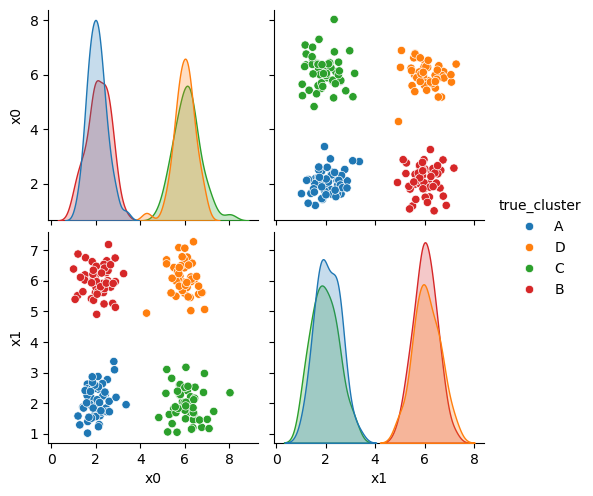

In [7]:
sns.pairplot(data=df, hue='true_cluster')


In [11]:
data_cols = ['x0','x1']

In [13]:
K =4
mu_0 = df[data_cols].sample(n=K).values
mu_0

array([[2.06, 5.56],
       [1.82, 2.47],
       [6.44, 2.16],
       [2.76, 5.26]])

In [15]:
i = 0

In [17]:
def mu_to_df(mu,i):
    mu_df = pd.DataFrame(mu,columns=['x0','x1'])
    mu_df['iteration'] = str(i)
    mu_df['class'] = ['M'+str(i) for i in range(K)]
    mu_df['type'] = 'mu'
    return mu_df

cmap_pt = sns.color_palette('tab20',8)[1::2]
cmap_mu = sns.color_palette('tab20',8)[0::2]

In [19]:
sns.color_palette('tab20',8)

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (1.0, 0.7333333333333333, 0.47058823529411764),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.596078431372549, 0.8745098039215686, 0.5411764705882353),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (1.0, 0.596078431372549, 0.5882352941176471)]

In [23]:
mu_df = mu_to_df(mu_0,i)
mu_df

,x0,x1,iteration,class,type
0,2.06,5.56,0,M0,mu
1,1.82,2.47,0,M1,mu
2,6.44,2.16,0,M2,mu
3,2.76,5.26,0,M3,mu


<Axes: xlabel='x0', ylabel='x1'>

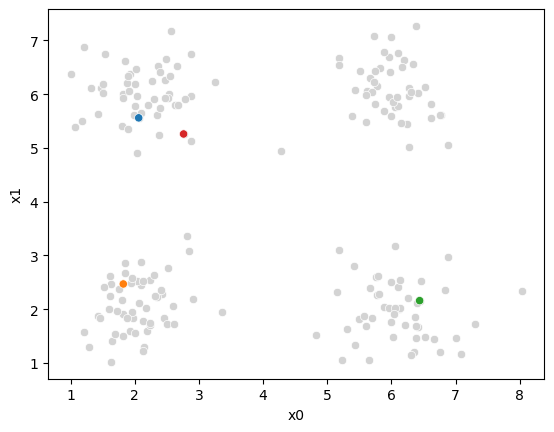

In [25]:
sfig = sns.scatterplot(data =df,x='x0',y='x1',color='lightgray',legend=False)
# plt.plot(mu[:,0],mu[:,1],marker='s',linewidth=0)
mu_df = mu_to_df(mu_0,i)
sns.scatterplot(data =mu_df,x='x0',y='x1',hue='class',palette=cmap_mu,ax=sfig,legend=False)


In [33]:
pd.concat([((df[data_cols]-mu_i)**2).sum(axis=1) for mu_i in mu_0],axis=1).head()


,0,1,2,3
0,10.8880,0.3961,16.1748,8.9960
1,18.2845,36.4900,20.0385,13.7105
2,15.7778,0.9113,18.3874,13.7938
3,46.0093,38.5810,2.5605,36.2993
4,0.6581,14.7866,32.5709,1.0841


In [35]:
pd.concat([((df[data_cols]-mu_i)**2).sum(axis=1) for mu_i in mu_0],axis=1).idxmin(axis=1)

0      1
1      3
2      1
3      2
4      0
      ..
195    0
196    3
197    1
198    3
199    2
Length: 200, dtype: int64

In [37]:
df[str(i)] = pd.concat([((df[data_cols]-mu_i)**2).sum(axis=1) for mu_i in mu_0],axis=1).idxmin(axis=1)
df.head()

,x0,x1,true_cluster,0
0,2.42,2.28,A,1
1,6.20,6.63,D,3
2,2.19,1.59,A,1
3,8.03,2.34,C,2
4,2.47,6.26,B,0


<Axes: xlabel='x0', ylabel='x1'>

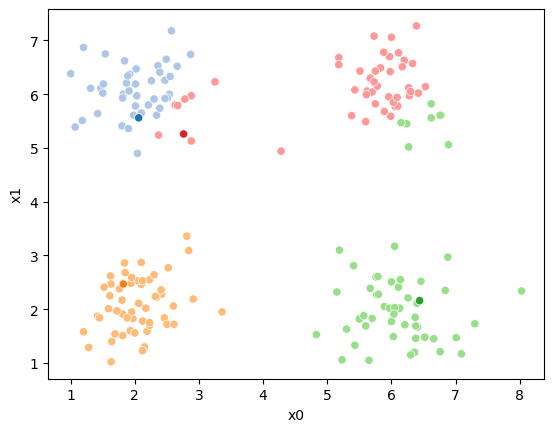

In [39]:
sfig = sns.scatterplot(data =df,x='x0',y='x1',hue='0',palette=cmap_pt,legend=False)
# plt.plot(mu[:,0],mu[:,1],marker='s',linewidth=0)
mu_df = mu_to_df(mu_0,i)
sns.scatterplot(data =mu_df,x='x0',y='x1',hue='class',palette=cmap_mu,ax=sfig,legend=False)

In [41]:
mu_1 = df.groupby('0')[data_cols].mean().values

<Axes: xlabel='x0', ylabel='x1'>

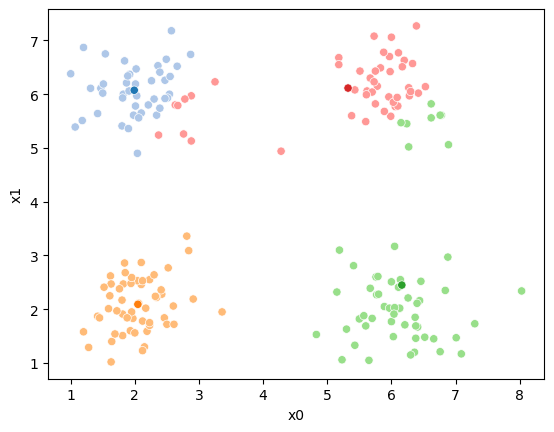

In [43]:
fig = plt.figure()
mu_df = mu_to_df(mu_1,1)
sfig = sns.scatterplot(data =df,x='x0',y='x1',hue='0',palette=cmap_pt,legend=False)
sns.scatterplot(data =mu_df,x='x0',y='x1',hue='class',palette=cmap_mu,ax=sfig,legend=False)


In [49]:
i=1 #increment 
df[str(i)] = pd.concat([((df[data_cols]-mu_i)**2).sum(axis=1) for mu_i in mu_1],axis=1).idxmin(axis=1)
df.head()

,x0,x1,true_cluster,0,1
0,2.42,2.28,A,1,1
1,6.20,6.63,D,3,3
2,2.19,1.59,A,1,1
3,8.03,2.34,C,2,2
4,2.47,6.26,B,0,0


<Axes: xlabel='x0', ylabel='x1'>

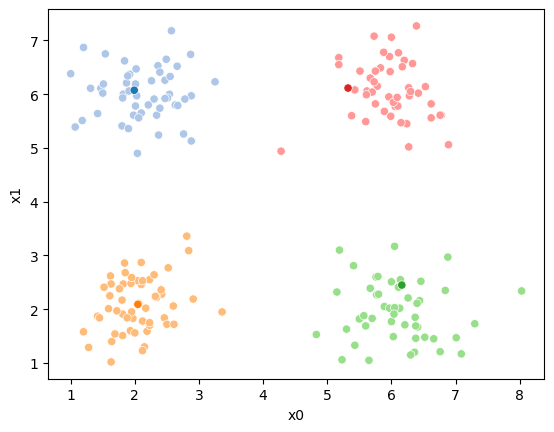

In [51]:
sfig = sns.scatterplot(data =df,x='x0',y='x1',hue=str(i),palette=cmap_pt,legend=False)
# plt.plot(mu[:,0],mu[:,1],marker='s',linewidth=0)
mu_df = mu_to_df(mu_1,i)
sns.scatterplot(data =mu_df,x='x0',y='x1',hue='class',palette=cmap_mu,ax=sfig,legend=False)

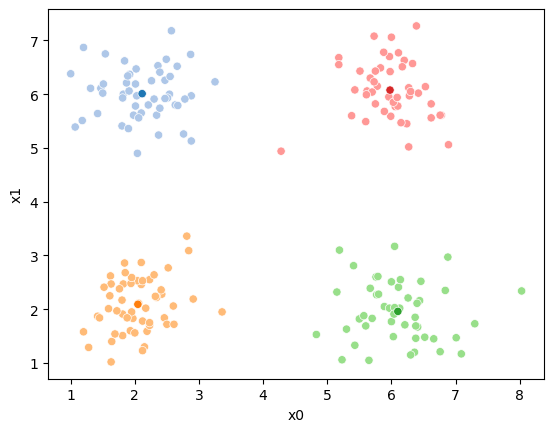

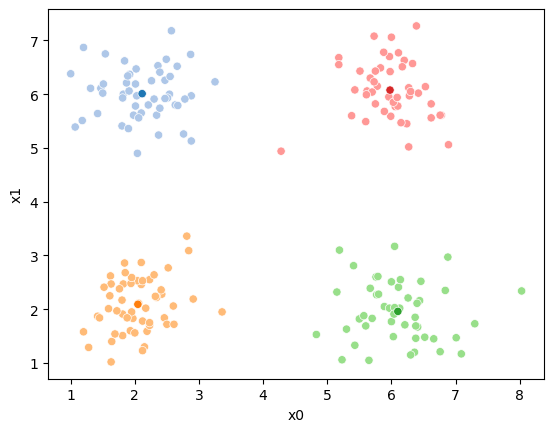

In [55]:
mu_list = [mu_to_df(mu_0,0),mu_to_df(mu_1,1)]
cur_old = str(i-1)
cur_new = str(i)
mu = mu_1
number_changed_assignments = sum(df[cur_old] !=df[cur_new])
while number_changed_assignments >0:
    cur_old = cur_new
    i +=1
    cur_new = str(i)
    #     update the means and plot with current generating assignments
    mu = df.groupby(cur_old)[data_cols].mean().values
    mu_df = mu_to_df(mu,i)
    mu_list.append(mu_df)

    fig = plt.figure()
    # plot with old assignments
    sfig = sns.scatterplot(data =df,x='x0',y='x1',hue=cur_old,palette=cmap_pt,legend=False)
    sns.scatterplot(data =mu_df,x='x0',y='x1',hue='class',palette=cmap_mu,ax=sfig,legend=False)
    #  save image to combine into a gif for the notes (do not need to do this)
    # file_num = str(i*2 -1).zfill(2)
    # sfig.get_figure().savefig('kmeans' +file_num + '.png')
    
    
    #     update the assigments and plot with the associated means
    df[cur_new] = pd.concat([((df[data_cols]-mu_i)**2).sum(axis=1) for mu_i in mu],axis=1).idxmin(axis=1)
    
    
    fig = plt.figure()
    sfig = sns.scatterplot(data =df,x='x0',y='x1',hue=cur_new,palette=cmap_pt,legend=False)
    sns.scatterplot(data =mu_df,x='x0',y='x1',hue='class',palette=cmap_mu,ax=sfig,legend=False)
    #  save image to combine into a gif for the notes (do not need to do this)
    # we are making 2 images per iteration
    # file_num = str(i*2).zfill(2)
    # sfig.get_figure().savefig('kmeans' +file_num + '.png')
    number_changed_assignments = sum(df[cur_old] !=df[cur_new])

In [58]:
iris_df = sns.load_dataset('iris')

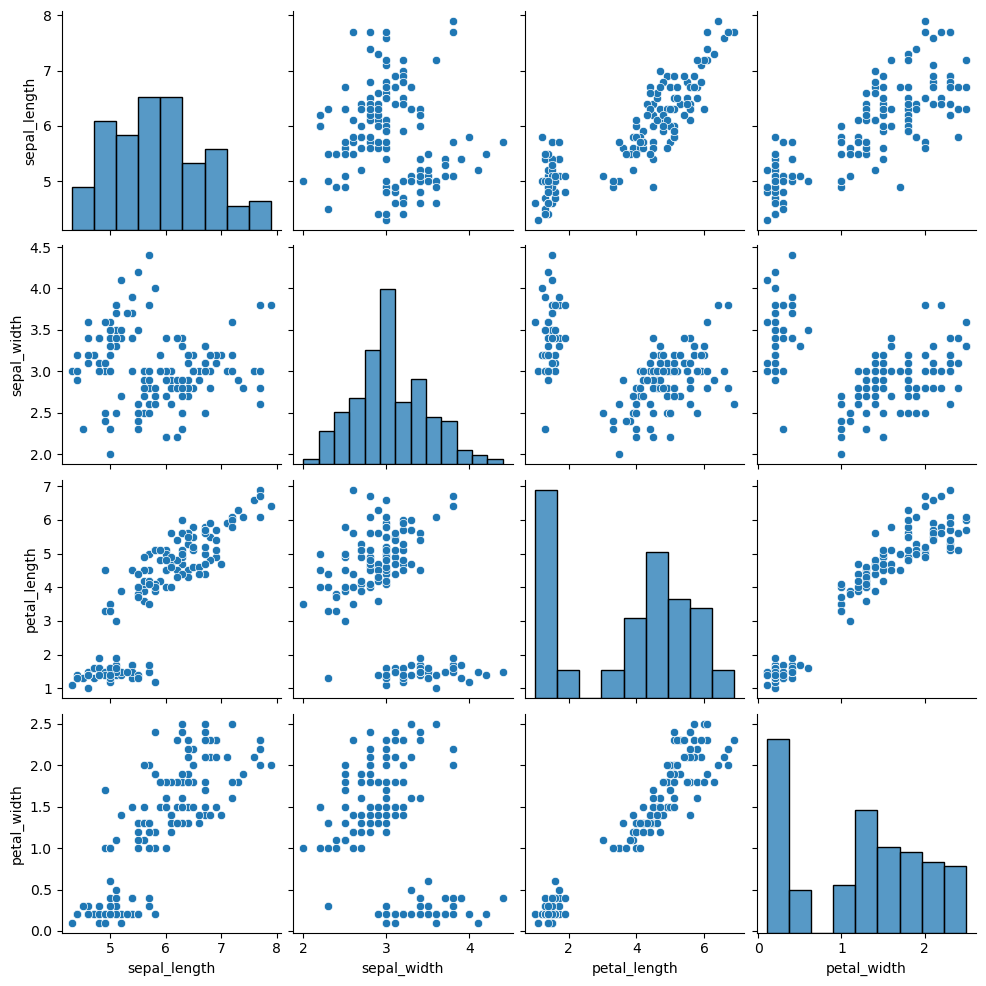

In [60]:
sns.pairplot(iris_df)

In [61]:
measurement_cols = ['sepal_length','petal_length','sepal_width','petal_width']
iris_X = iris_df[measurement_cols]

In [62]:
km = KMeans(n_clusters=3)

In [66]:
y_pred = km3.fit_predict(iris_X)

NameError: name 'km3' is not defined